# EDA & Preprocessing

### Importing libraries and Loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Final_Augmented_dataset_Diseases_and_Symptoms.csv')
df = df.rename(columns={'diseases': 'disease'})

symptom_cols = [c for c in df.columns if c != 'disease']

print(f"Shape          : {df.shape}")
print(f"Diseases       : {df['disease'].nunique()}")
print(f"Symptom columns: {len(symptom_cols)}")
print(f"Missing values : {df.isnull().sum().sum()}")

Shape          : (246945, 378)
Diseases       : 773
Symptom columns: 377
Missing values : 0


### Class Distribution

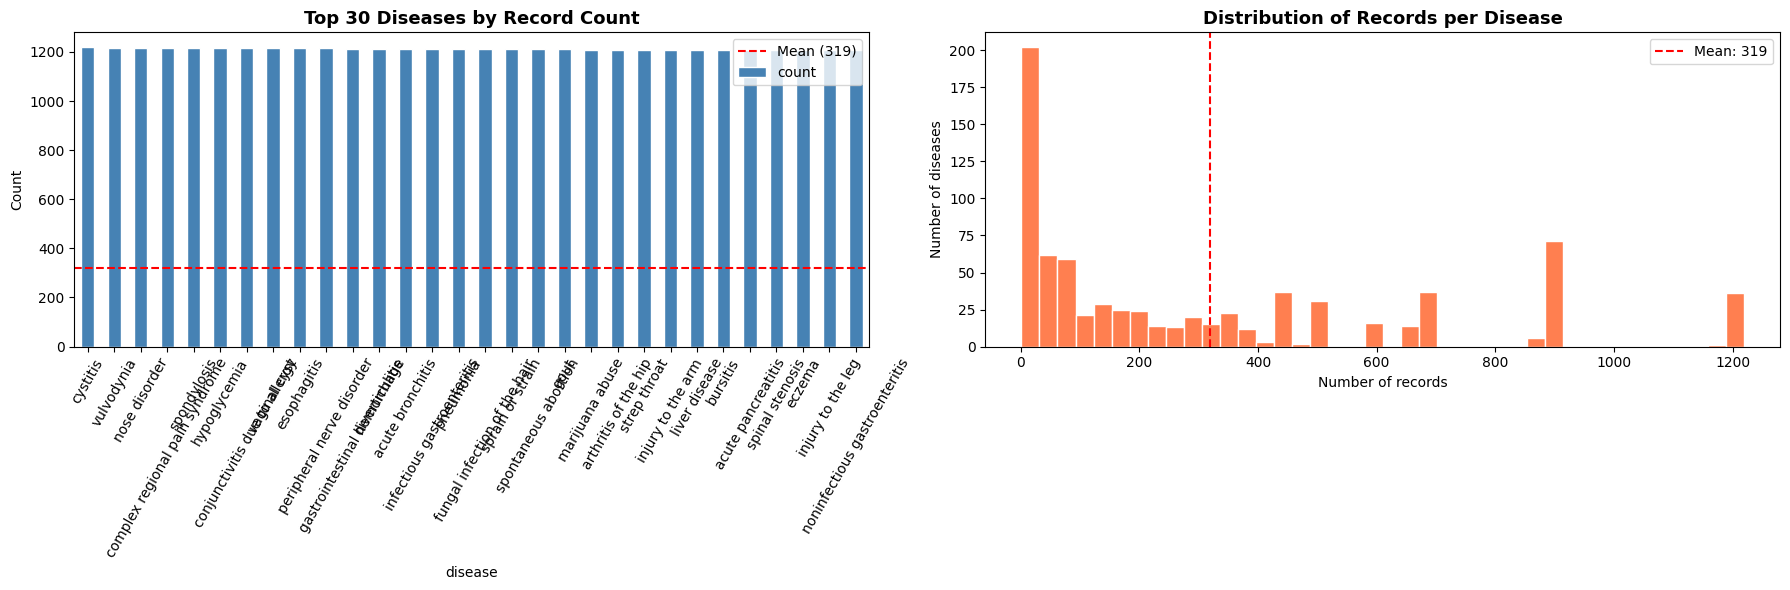

Min records per disease : 1
Max records per disease : 1219
Mean records per disease: 319.5


In [2]:
disease_counts = df['disease'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 30 diseases
disease_counts.head(30).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 30 Diseases by Record Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=60)
axes[0].axhline(y=disease_counts.mean(), color='red', linestyle='--', label=f'Mean ({disease_counts.mean():.0f})')
axes[0].legend()

# Distribution of counts (is it balanced?)
axes[1].hist(disease_counts.values, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Records per Disease', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of records')
axes[1].set_ylabel('Number of diseases')
axes[1].axvline(disease_counts.mean(), color='red', linestyle='--', label=f'Mean: {disease_counts.mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Min records per disease : {disease_counts.min()}")
print(f"Max records per disease : {disease_counts.max()}")
print(f"Mean records per disease: {disease_counts.mean():.1f}")

### Symptom frequency analysis

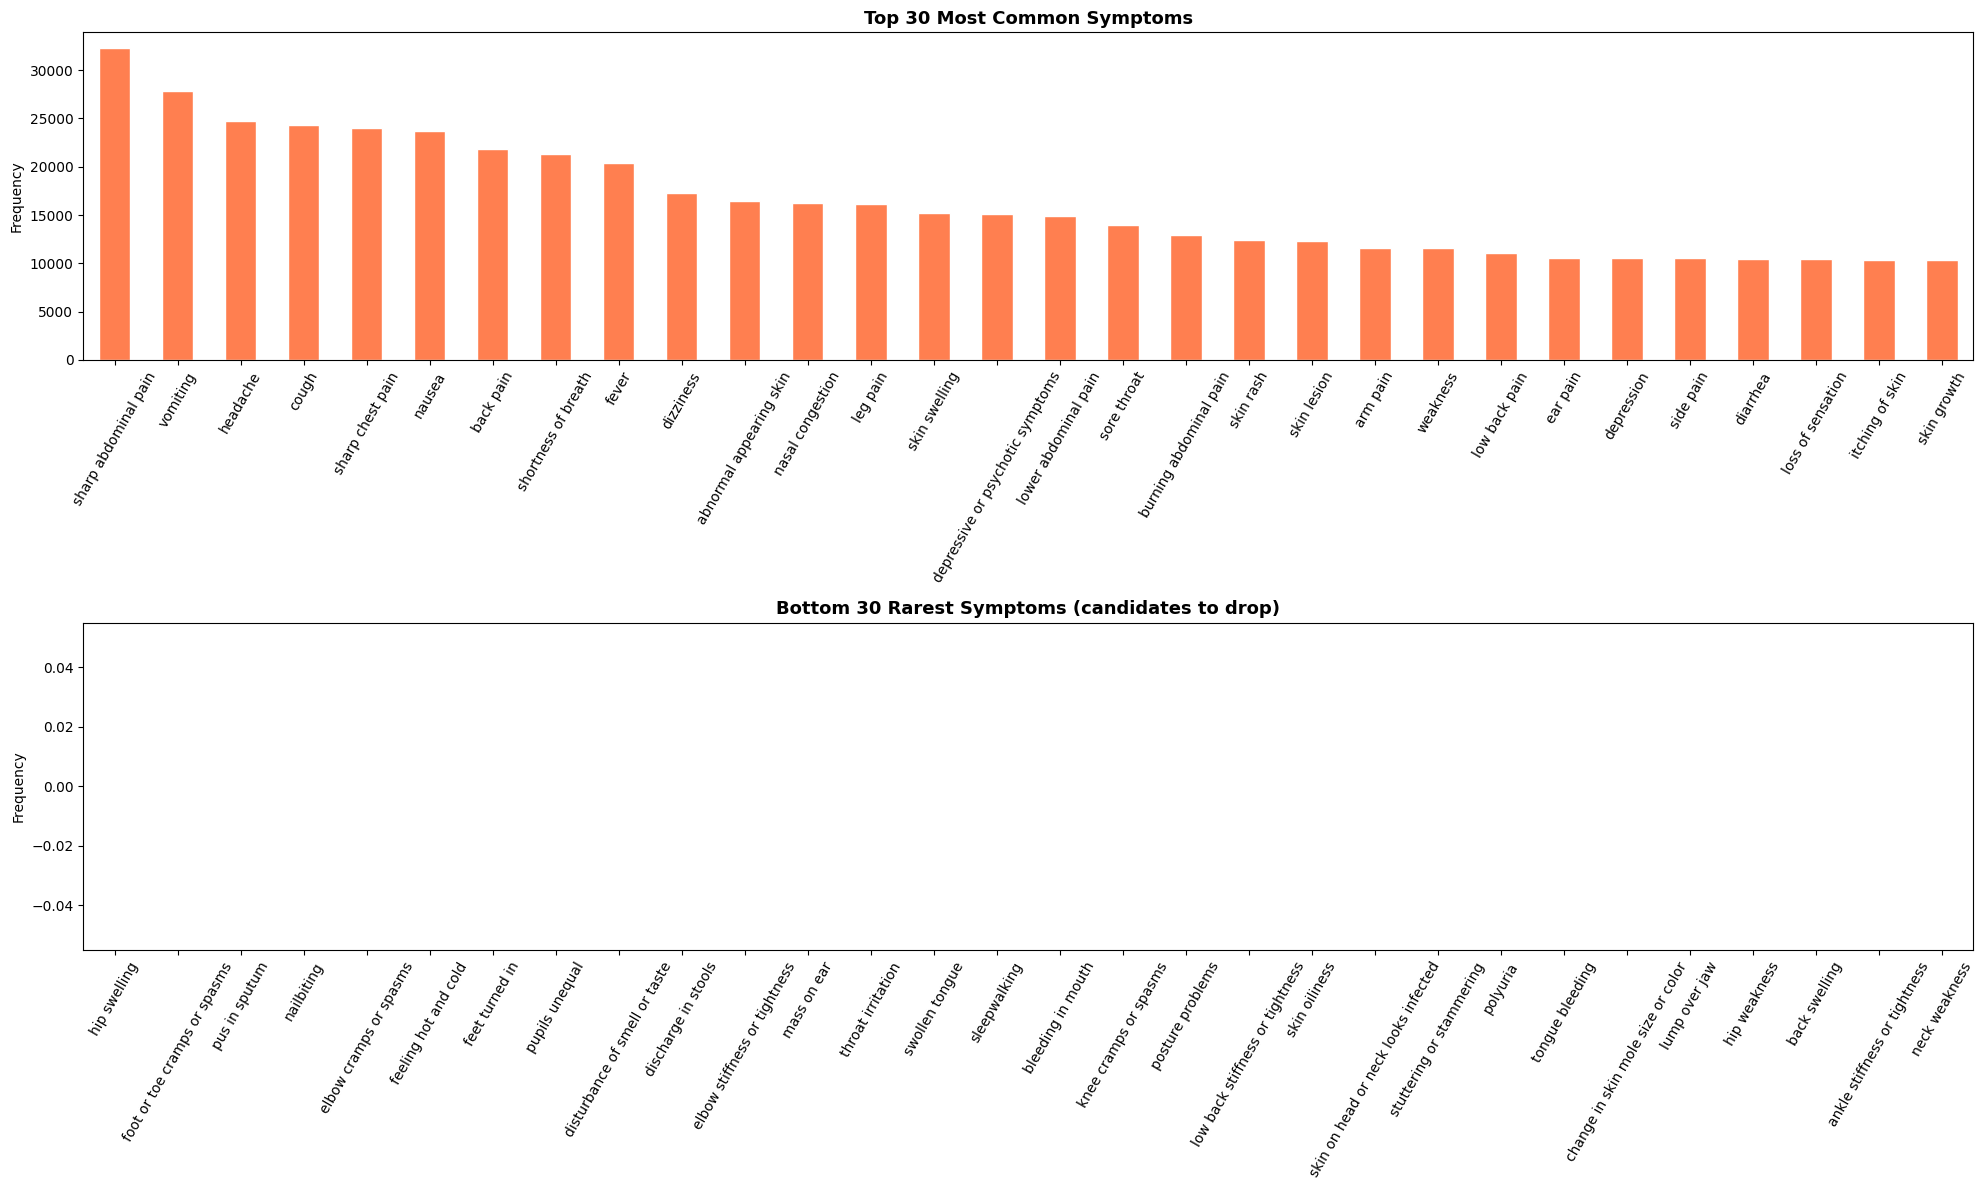

Most common symptom : sharp abdominal pain (32,307 records)
Least common symptom: neck weakness (0 records)


In [3]:
symptom_freq = df[symptom_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(20, 12))

symptom_freq.head(30).plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Top 30 Most Common Symptoms', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=60)

symptom_freq.tail(30).plot(kind='bar', ax=axes[1], color='lightblue', edgecolor='white')
axes[1].set_title('Bottom 30 Rarest Symptoms (candidates to drop)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.savefig('symptom_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most common symptom : {symptom_freq.index[0]} ({symptom_freq.iloc[0]:,} records)")
print(f"Least common symptom: {symptom_freq.index[-1]} ({symptom_freq.iloc[-1]:,} records)")

### Disease-symptom heatmap (top 25 diseases, top 40 symptoms)

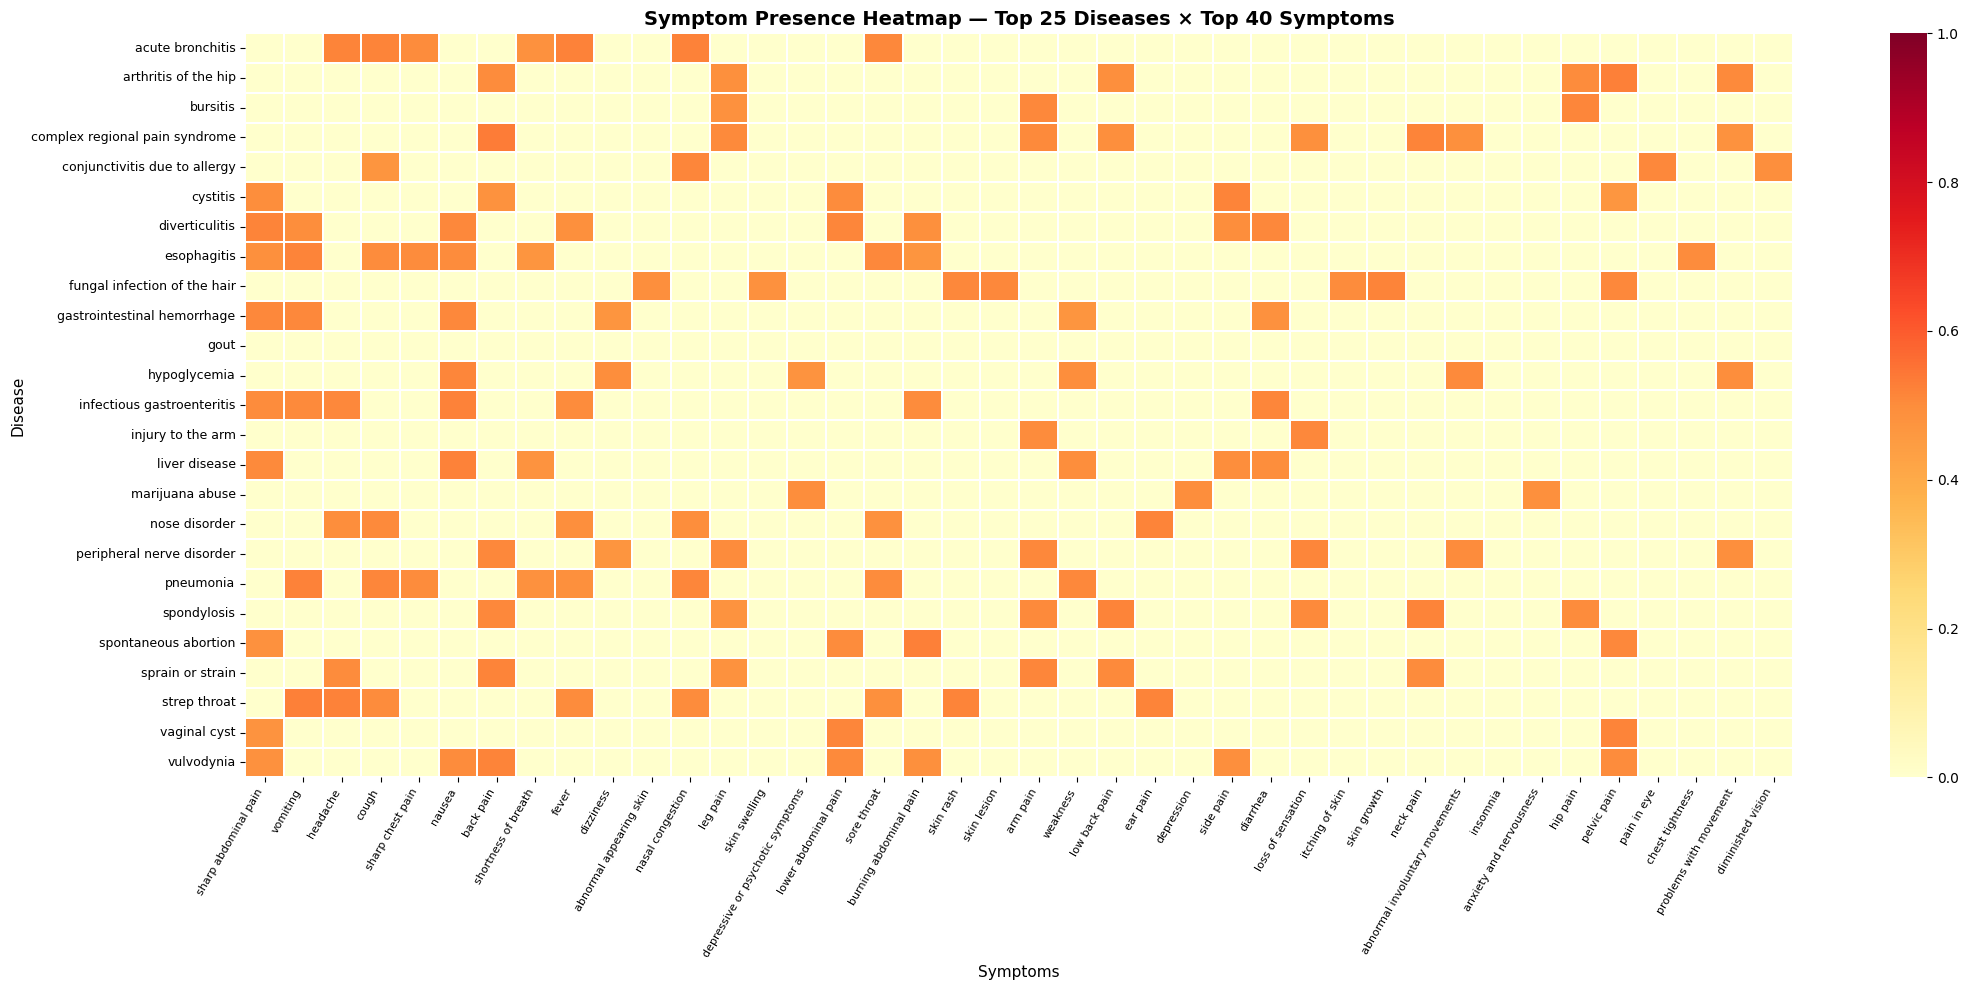

In [4]:
# Subset for readability
top_diseases = disease_counts.head(25).index.tolist()
top_symptoms = symptom_freq.head(40).index.tolist()

heatmap_data = df[df['disease'].isin(top_diseases)].groupby('disease')[top_symptoms].mean()

plt.figure(figsize=(22, 10))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    linecolor='white',
    vmin=0, vmax=1
)
plt.title('Symptom Presence Heatmap — Top 25 Diseases × Top 40 Symptoms',
          fontsize=14, fontweight='bold')
plt.xlabel('Symptoms', fontsize=11)
plt.ylabel('Disease', fontsize=11)
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('symptom_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

# Step 1: Remove low-variance symptoms
print("STEP 1: Remove low-variance symptoms")
selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(df[symptom_cols])
kept_cols = [symptom_cols[i] for i in range(len(symptom_cols)) if selector.get_support()[i]]
print(f"  Before : {len(symptom_cols)} symptoms")
print(f"  After  : {len(kept_cols)} symptoms")
print(f"  Dropped: {len(symptom_cols) - len(kept_cols)} symptoms")

# Step 2: Remove diseases with fewer than 10 records (can't stratify)
print("\nSTEP 2: Filter rare diseases")
disease_counts = df['disease'].value_counts()
valid_diseases = disease_counts[disease_counts >= 10].index  # keep diseases with 10+ records
df_clean = df[df['disease'].isin(valid_diseases)].reset_index(drop=True)
print(f"  Diseases before : {df['disease'].nunique()}")
print(f"  Diseases after  : {df_clean['disease'].nunique()}")
print(f"  Rows before     : {len(df):,}")
print(f"  Rows after      : {len(df_clean):,}")
print(f"  Removed diseases: {df['disease'].nunique() - df_clean['disease'].nunique()}")

# Step 3: Encode labels
print("\nSTEP 3: Encode disease labels")
le = LabelEncoder()
X = df_clean[kept_cols]
y = le.fit_transform(df_clean['disease'])
print(f"  Total classes: {len(le.classes_)}")

# Step 4: Train / Val / Test split — 70 / 15 / 15
print("\nSTEP 4: Train/Val/Test split (70/15/15)")
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")

print("\nPreprocessing complete ✓")

STEP 1: Remove low-variance symptoms
  Before : 377 symptoms
  After  : 146 symptoms
  Dropped: 231 symptoms

STEP 2: Filter rare diseases
  Diseases before : 773
  Diseases after  : 677
  Rows before     : 246,945
  Rows after      : 246,512
  Removed diseases: 96

STEP 3: Encode disease labels
  Total classes: 677

STEP 4: Train/Val/Test split (70/15/15)
  Train : (172558, 146)
  Val   : (36977, 146)
  Test  : (36977, 146)

Preprocessing complete ✓


### Saving for Phase 2

In [6]:
import pickle

splits = {
    'X_train': X_train,
    'X_val'  : X_val,
    'X_test' : X_test,
    'y_train': y_train,
    'y_val'  : y_val,
    'y_test' : y_test,
    'feature_names' : kept_cols,
    'label_encoder' : le,
    'disease_names' : list(le.classes_)
}

with open('medisense_preprocessed.pkl', 'wb') as f:
    pickle.dump(splits, f)

print("Saved: medisense_preprocessed.pkl ✓")
print(f"\nReady for Phase 3:")
print(f"  Training samples : {X_train.shape[0]:,}")
print(f"  Val samples      : {X_val.shape[0]:,}")
print(f"  Test samples     : {X_test.shape[0]:,}")
print(f"  Features         : {len(kept_cols)}")
print(f"  Disease classes  : {len(le.classes_)}")

Saved: medisense_preprocessed.pkl ✓

Ready for Phase 3:
  Training samples : 172,558
  Val samples      : 36,977
  Test samples     : 36,977
  Features         : 146
  Disease classes  : 677
